# 镇龙乡 30 m DEM：完整预处理、八图层生成与双图运行记录

本 Notebook 从以下原始 DEM 路径开始：

`C:\Users\86133\Downloads\镇龙乡及周边30米DEM.tif`

无需读取预先修正的 DEM。代码内嵌 16 个控制节点，现场计算八种候选图层、逐节点留一交叉验证、诊断数据及两张正式图：

1. **图 P1**：1×4 误差分布与森林图诊断；
2. **图 P2**：八种 DEM 的全域与 A/B/C 三处局部放大对比。

图形样式参考所提供代码包中的森林图、水平误差棒、柱状散点组合与棒棒糖图，并统一使用 `RdYlBu_r` 连续渐变。

## 1. 环境、原始路径与运行日志

In [2]:
from pathlib import Path
from datetime import datetime
import json, math, time, warnings
import numpy as np
import pandas as pd
from PIL import Image, TiffImagePlugin
from scipy.ndimage import map_coordinates
from scipy.optimize import least_squares
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern
from sklearn.exceptions import ConvergenceWarning

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, patches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import Normalize, TwoSlopeNorm, LightSource
from matplotlib.cm import ScalarMappable
from IPython.display import display

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "Nimbus Sans", "Droid Sans Fallback", "DejaVu Sans"],
    "axes.unicode_minus": False, "mathtext.fontset": "stixsans",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

def log(message):
    print(f"[{datetime.now():%Y-%m-%d %H:%M:%S}] {message}")

# 用户电脑上的正式输入路径
USER_RAW_DEM_PATH = Path(r"C:\Users\86133\Downloads\镇龙乡及周边30米DEM.tif")

# 仅用于本 Notebook 在当前工作空间中的复现检查；用户电脑上会直接使用上面的 Windows 路径。
HERE = Path.cwd()
if not (HERE / "plot_dem_diagnostics.py").exists() and (HERE / "q1_robust_exact").exists():
    HERE = HERE / "q1_robust_exact"
LOCAL_FONT = HERE.parent / "中文字体_绘图临时.otf"
if LOCAL_FONT.exists():
    font_manager.fontManager.addfont(str(LOCAL_FONT))
# 当前工作空间优先使用已随项目提供的中文字体；在用户的 Windows 环境中
# 若该字体不存在，则自动回退到微软雅黑/黑体。
if LOCAL_FONT.exists():
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(LOCAL_FONT)).get_name()
else:
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    chinese_font = next((name for name in ("Microsoft YaHei", "SimHei", "Arial Unicode MS")
                         if name in available_fonts), "DejaVu Sans")
    plt.rcParams["font.family"] = chinese_font
LOCAL_FALLBACK = HERE.parent / "upload" / "镇龙乡及周边30米DEM.tif"
if USER_RAW_DEM_PATH.exists():
    SOURCE = USER_RAW_DEM_PATH
    OUTPUT_ROOT = USER_RAW_DEM_PATH.parent / "DEM预处理输出"
else:
    SOURCE = LOCAL_FALLBACK
    OUTPUT_ROOT = HERE / "Notebook预处理输出"
assert SOURCE.exists(), f"未找到原始 DEM：{USER_RAW_DEM_PATH}"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NODE_RECORDS = [{'node_id': 'O01', 'name': '凤丹村无人机调度中心', 'longitude_deg': 109.2308517, 'latitude_deg': 23.0085095, 'ground_elevation_m': 127.7}, {'node_id': 'S001', 'name': '平旺、那龙、镇龙乡', 'longitude_deg': 109.2432319, 'latitude_deg': 23.0335927, 'ground_elevation_m': 154.0}, {'node_id': 'S002', 'name': '上良', 'longitude_deg': 109.2585519, 'latitude_deg': 23.0703271, 'ground_elevation_m': 189.5}, {'node_id': 'S003', 'name': '六造、那旭、都长', 'longitude_deg': 109.1688578, 'latitude_deg': 23.0402714, 'ground_elevation_m': 308.5}, {'node_id': 'S004', 'name': '大站', 'longitude_deg': 109.2381714, 'latitude_deg': 23.0778414, 'ground_elevation_m': 198.3}, {'node_id': 'S005', 'name': '上良、古律、那麓', 'longitude_deg': 109.2283003, 'latitude_deg': 23.0561338, 'ground_elevation_m': 165.0}, {'node_id': 'S006', 'name': '六昌、木路', 'longitude_deg': 109.1997836, 'latitude_deg': 23.007714, 'ground_elevation_m': 284.8}, {'node_id': 'S007', 'name': '佛子、那桑、银坑', 'longitude_deg': 109.1928191, 'latitude_deg': 23.0294186, 'ground_elevation_m': 318.5}, {'node_id': 'S008', 'name': '古麻、大站', 'longitude_deg': 109.2127472, 'latitude_deg': 23.0795113, 'ground_elevation_m': 240.9}, {'node_id': 'S009', 'name': '那龙', 'longitude_deg': 109.2541424, 'latitude_deg': 23.0552989, 'ground_elevation_m': 200.0}, {'node_id': 'S010', 'name': '镇龙乡', 'longitude_deg': 109.2760168, 'latitude_deg': 23.0194009, 'ground_elevation_m': 321.6}, {'node_id': 'S011', 'name': '那从', 'longitude_deg': 109.2203356, 'latitude_deg': 23.0319231, 'ground_elevation_m': 182.1}, {'node_id': 'S012', 'name': '镇龙乡', 'longitude_deg': 109.2831357, 'latitude_deg': 23.054464, 'ground_elevation_m': 249.8}, {'node_id': 'S013', 'name': '镇龙乡', 'longitude_deg': 109.2713839, 'latitude_deg': 23.0310882, 'ground_elevation_m': 321.7}, {'node_id': 'S014', 'name': '镇龙乡', 'longitude_deg': 109.2835966, 'latitude_deg': 23.0052097, 'ground_elevation_m': 321.0}, {'node_id': 'S015', 'name': '六造、那托、那旭', 'longitude_deg': 109.1923786, 'latitude_deg': 23.0494548, 'ground_elevation_m': 444.5}]
NODES_TABLE = pd.DataFrame(NODE_RECORDS)
log(f"原始 DEM：{SOURCE}")
log(f"输出目录：{OUTPUT_ROOT}")
log(f"内嵌控制节点：{len(NODES_TABLE)} 个")

[2026-09-23 09:09:53] 原始 DEM：C:\Users\86133\Downloads\镇龙乡及周边30米DEM.tif
[2026-09-23 09:09:53] 输出目录：C:\Users\86133\Downloads\DEM预处理输出
[2026-09-23 09:09:53] 内嵌控制节点：16 个


## 2. 读取 GeoTIFF 与建立坐标基准

In [3]:
def utm49(lon: float, lat: float):
    a, e2, k0 = 6378137.0, 0.0066943799901413165, 0.9996
    phi, dl = math.radians(lat), math.radians(lon - 111.0)
    ep2 = e2/(1-e2); s, c, t = math.sin(phi), math.cos(phi), math.tan(phi)**2
    C, A = ep2*c*c, c*dl; N0 = a/math.sqrt(1-e2*s*s)
    M = a*((1-e2/4-3*e2**2/64-5*e2**3/256)*phi
           -(3*e2/8+3*e2**2/32+45*e2**3/1024)*math.sin(2*phi)
           +(15*e2**2/256+45*e2**3/1024)*math.sin(4*phi)
           -(35*e2**3/3072)*math.sin(6*phi))
    x = 500000+k0*N0*(A+(1-t+C)*A**3/6+(5-18*t+t*t+72*C-58*ep2)*A**5/120)
    y = k0*(M+N0*math.tan(phi)*(A*A/2+(5-t+9*C+4*C*C)*A**4/24
                                 +(61-58*t+t*t+600*C-330*ep2)*A**6/720))
    return x, y

def read_dem(path: Path):
    with Image.open(path) as image:
        dem=np.asarray(image,dtype=np.float32).copy()
        scale,point=image.tag_v2[33550],image.tag_v2[33922]
        keys=tuple(image.tag_v2[34735])
        raster_type=next((keys[i+3] for i in range(4,len(keys),4) if keys[i]==1025),None)
        dx,dy=float(scale[0]),float(scale[1])
        assert dem.ndim==2 and np.isfinite(dem).all() and raster_type in (1,2)
        left=float(point[3])-(dx/2 if raster_type==2 else 0)
        top=float(point[4])+(dy/2 if raster_type==2 else 0)
        return dem,left,top,dx,dy

ORIGINAL,LEFT,TOP,DX,DY=read_dem(SOURCE)
z=ORIGINAL.astype(np.float64)
NODES=NODES_TABLE.copy()
lon=NODES.longitude_deg.to_numpy(float); lat=NODES.latitude_deg.to_numpy(float)
target=NODES.ground_elevation_m.to_numpy(float)
positions=np.array([utm49(x,y) for x,y in zip(lon,lat)])
pos_center=positions.mean(axis=0); xy_km=(positions-pos_center)/1000
center_r=(TOP-lat)/DY-.5; center_c=(lon-LEFT)/DX-.5
meters_lon=111320*math.cos(math.radians(float(lat.mean()))); meters_lat=111320.0
N=len(target); index_all=np.arange(N); shape=ORIGINAL.shape
log(f"DEM 尺寸：{shape[0]}×{shape[1]}；像元尺度：{DX:.8f}°×{DY:.8f}°")

[2026-09-23 09:09:59] DEM 尺寸：1309×1486；像元尺度：0.00027778°×0.00027778°


## 3. 八种候选校正模型与留一交叉验证函数

In [4]:
def sample_shifted(params, ids):
    shift_e, shift_n, bias = params
    rr = center_r[ids] - shift_n/meters_lat/DY
    cc = center_c[ids] + shift_e/meters_lon/DX
    return map_coordinates(z, np.vstack([rr, cc]),
                           order=1, mode="nearest", prefilter=False)+bias


raw_samples = sample_shifted([0, 0, 0], index_all)
residuals = target-raw_samples


def trend_fit(ids, robust=False):
    X = np.c_[np.ones(len(ids)), xy_km[ids]]
    if robust:
        fit = least_squares(lambda b: X@b-residuals[ids],
                            np.linalg.lstsq(X,residuals[ids],rcond=None)[0],
                            loss="huber", f_scale=2.0)
        return fit.x
    return np.linalg.lstsq(X, residuals[ids], rcond=None)[0]


def shift_fit(ids, robust=False):
    fit = least_squares(lambda p: sample_shifted(p, ids)-target[ids],
                        x0=np.zeros(3), bounds=([-30,-30,-20], [30,30,20]),
                        loss="huber" if robust else "linear", f_scale=2.0,
                        diff_step=1e-3, max_nfev=250)
    if not fit.success:
        raise RuntimeError("三维配准未收敛："+fit.message)
    return fit.x


def gp_fit(ids, kind):
    kernel = ConstantKernel(3.0, (0.1, 30.0)) * (
        RBF(1500, (150, 10000)) if kind == "rbf"
        else Matern(1500, (150, 10000), nu=1.5))
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-5,
                                  n_restarts_optimizer=1, normalize_y=True,
                                  random_state=7)
    gp.fit(positions[ids], residuals[ids])
    return gp


def cv_estimates(name):
    estimates = np.empty(N)
    if name == "raw":
        estimates = raw_samples.copy()
    else:
        for i in range(N):
            train = index_all[index_all != i]
            if name == "bias":
                estimates[i] = raw_samples[i]+float(np.median(residuals[train]))
            elif name in ("trend", "robust_trend"):
                b = trend_fit(train, robust=name=="robust_trend")
                estimates[i] = raw_samples[i]+np.dot(np.r_[1.,xy_km[i]],b)
            elif name in ("ls", "robust"):
                p = shift_fit(train, robust=name=="robust")
                estimates[i] = sample_shifted(p,np.array([i]))[0]
            elif name in ("rbf", "matern"):
                model = gp_fit(train, name)
                estimates[i] = raw_samples[i]+model.predict(positions[i:i+1])[0]
            else:
                raise ValueError(name)
    return estimates


def cv_metrics(name):
    estimates = cv_estimates(name)
    err = estimates-target
    return dict(留一均方根误差米=float(np.sqrt(np.mean(err**2))),
                留一平均绝对误差米=float(np.mean(abs(err))))


def xy_raster(row_start, row_stop):
    rows = np.arange(row_start,row_stop)[:,None]+.5
    cols = np.arange(shape[1])[None,:]+.5
    grid_lat = TOP-DY*rows
    grid_lon = LEFT+DX*cols
    # 小区域 WGS84 的米制近似只用于 GPR 网格预测，节点拟合采用 UTM49。
    anchor_lon,anchor_lat=lon.mean(),lat.mean()
    anchor=utm49(anchor_lon,anchor_lat)
    east = anchor[0]+(grid_lon-anchor_lon)*meters_lon
    north = anchor[1]+(grid_lat-anchor_lat)*meters_lat
    X,Y=np.broadcast_arrays(east,north)
    return np.column_stack([X.ravel(),Y.ravel()])


def save_product(path, data):
    with Image.open(SOURCE) as source:
        tif = TiffImagePlugin.ImageFileDirectory_v2()
        for tag in (33550,33922,34735,34736,34737,42113):
            if tag in source.tag_v2:
                tif[tag] = source.tag_v2[tag]
    Image.fromarray(np.asarray(data,dtype=np.float32),mode="F").save(
        path, format="TIFF", compression="tiff_adobe_deflate", tiffinfo=tif)


def generate():
    r0 = np.arange(shape[0],dtype=float)[:,None]
    c0 = np.arange(shape[1],dtype=float)[None,:]
    params = {"bias":float(np.median(residuals)),
              "trend":trend_fit(index_all).tolist(),
              "robust_trend":trend_fit(index_all,robust=True).tolist(),
              "ls":shift_fit(index_all).tolist(),
              "robust_reestimated":shift_fit(index_all,robust=True).tolist()}
    products = {"raw":ORIGINAL,
                "bias":np.asarray(z+params["bias"],dtype=np.float32)}
    lon_ref,lat_ref=lon.mean(),lat.mean()
    x_ref,y_ref=utm49(lon_ref,lat_ref)
    x_raster=x_ref+((LEFT+(c0+.5)*DX)-lon_ref)*meters_lon
    y_raster=y_ref+((TOP-(r0+.5)*DY)-lat_ref)*meters_lat
    xc=(x_raster-pos_center[0])/1000
    yc=(y_raster-pos_center[1])/1000
    for kind in ("trend","robust_trend"):
        b=params[kind]
        products[kind]=np.asarray(z+b[0]+b[1]*xc+b[2]*yc,dtype=np.float32)
    east,north,bias=params["ls"]
    sampled=map_coordinates(z,[r0-north/meters_lat/DY+np.zeros_like(c0),
                               c0+east/meters_lon/DX+np.zeros_like(r0)],
                            order=1,mode="nearest",prefilter=False)
    products["ls"]=np.asarray(sampled+bias,dtype=np.float32)
    east,north,bias=params["robust_reestimated"]
    sampled=map_coordinates(z,[r0-north/meters_lat/DY+np.zeros_like(c0),
                               c0+east/meters_lon/DX+np.zeros_like(r0)],
                            order=1,mode="nearest",prefilter=False)
    products["robust"]=np.asarray(sampled+bias,dtype=np.float32)

    for kind in ("rbf","matern"):
        gp=gp_fit(index_all,kind)
        fitted=np.empty(shape,dtype=np.float32)
        for r in range(0,shape[0],36):
            stop=min(shape[0],r+36)
            predicted=gp.predict(xy_raster(r,stop)).reshape(stop-r,shape[1])
            fitted[r:stop]=np.asarray(z[r:stop]+predicted,dtype=np.float32)
        products[kind]=fitted
        params[kind] = dict(核=str(gp.kernel_),噪声方差=float(gp.alpha))
    return products,params

## 4. 运行数据预处理并导出八种 DEM 图层

In [5]:
t0=time.perf_counter(); log("开始 DEM 预处理与候选模型拟合")
with warnings.catch_warnings():
    warnings.simplefilter("ignore",ConvergenceWarning)
    products,params=generate()

layer_dir=OUTPUT_ROOT/"八种DEM产品"; layer_dir.mkdir(exist_ok=True)
layer_names={"raw":"a_原始高程","bias":"b_垂直偏差_中位数","trend":"c_线性趋势",
       "robust_trend":"d_稳健趋势","ls":"e_最小二乘三维配准",
       "robust":"f_稳健三维配准","rbf":"g_高斯过程_径向基","matern":"h_高斯过程_马特恩"}
rows=[]; node_rows=[]
with warnings.catch_warnings():
    warnings.simplefilter("ignore",ConvergenceWarning)
    for kind,data in products.items():
        save_product(layer_dir/f"{layer_names[kind]}.tif",data)
        estimates=cv_estimates(kind); errors=estimates-target
        rmse=float(np.sqrt(np.mean(errors**2))); mae=float(np.mean(np.abs(errors)))
        for node_id,observed,estimated,error in zip(NODES.node_id,target,estimates,errors):
            node_rows.append({"产品代号":kind,"节点":node_id,"节点高程米":observed,
                              "留一预测高程米":estimated,"留一误差米":error,"留一绝对误差米":abs(error)})
        diff=np.asarray(data,dtype=float)-z
        rows.append({"方法":layer_names[kind],"产品代号":kind,"留一均方根误差米":rmse,
                     "留一平均绝对误差米":mae,"对原图平均变化米":float(np.mean(diff)),
                     "对原图变化百分位95米":float(np.quantile(np.abs(diff),.95)),
                     "对原图变化最小米":float(diff.min()),"对原图变化最大米":float(diff.max())})
METRICS=pd.DataFrame(rows); ERRORS=pd.DataFrame(node_rows); PARAMS=params
METRICS.to_csv(OUTPUT_ROOT/"09_八种DEM交叉验证与差异.csv",index=False,encoding="utf-8-sig",float_format="%.6f")
ERRORS.to_csv(OUTPUT_ROOT/"11_八种DEM节点留一误差.csv",index=False,encoding="utf-8-sig",float_format="%.6f")
(OUTPUT_ROOT/"10_候选模型参数.json").write_text(json.dumps(params,ensure_ascii=False,indent=2),encoding="utf-8")
log(f"完成：8 个 GeoTIFF、2 个 CSV、1 个 JSON；耗时 {time.perf_counter()-t0:.2f} 秒")
display(METRICS[["方法","留一均方根误差米","留一平均绝对误差米","对原图变化百分位95米"]].round(3))

[2026-09-23 09:10:22] 开始 DEM 预处理与候选模型拟合
[2026-09-23 09:10:28] 完成：8 个 GeoTIFF、2 个 CSV、1 个 JSON；耗时 5.66 秒


,方法,留一均方根误差米,留一平均绝对误差米,对原图变化百分位95米
0,a_原始高程,4.239,3.004,0.000
1,b_垂直偏差_中位数,4.468,3.299,0.055
2,c_线性趋势,4.739,3.732,8.504
3,d_稳健趋势,4.740,3.534,6.660
4,e_最小二乘三维配准,4.197,2.999,8.233
5,f_稳健三维配准,4.058,3.055,9.248
6,g_高斯过程_径向基,4.418,3.536,1.259
7,h_高斯过程_马特恩,4.370,3.465,1.259


## 5. 图 P1：一行四列误差与森林图诊断

[2026-09-23 09:10:33] 开始绘制图 P1
[2026-09-23 09:10:34] 图 P1 完成：C:\Users\86133\Downloads\DEM预处理输出\图P1_DEM校正诊断与模型筛选.png；耗时 0.91 秒


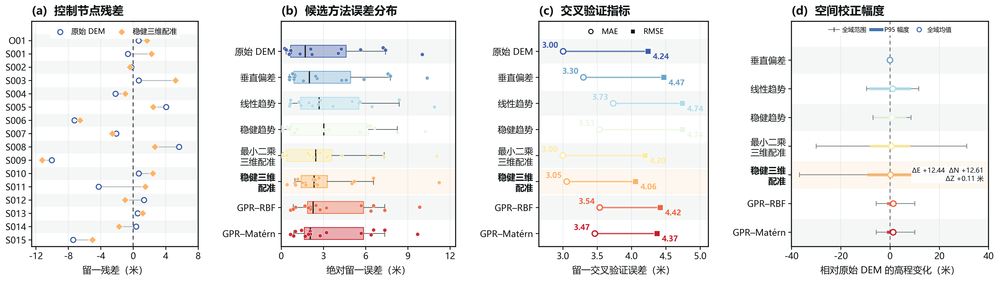

In [6]:
ORDER = ["raw", "bias", "trend", "robust_trend", "ls", "robust", "rbf", "matern"]
LABELS = {
    "raw": "原始 DEM",
    "bias": "垂直偏差",
    "trend": "线性趋势",
    "robust_trend": "稳健趋势",
    "ls": "最小二乘\n三维配准",
    "robust": "稳健三维\n配准",
    "rbf": "GPR–RBF",
    "matern": "GPR–Matérn",
}

CMAP = plt.get_cmap("RdYlBu_r")
BLUE = CMAP(0.10)
PALE_BLUE = CMAP(0.22)
ORANGE = CMAP(0.74)
WINE = CMAP(0.94)
METHOD_COLORS = {code: CMAP(v) for code, v in zip(ORDER, np.linspace(.06, .94, len(ORDER)))}
INK = "#111516"
MID = "#586166"
GRID = "#c7cbcd"
LIGHT = "#f3f4f4"


def style_axis(ax, grid_axis="y"):
    ax.set_facecolor("white")
    ax.tick_params(axis="both", which="major", direction="out", length=5.0,
                   width=1.35, labelsize=14.2, pad=4, colors=INK)
    for spine in ax.spines.values():
        spine.set_linewidth(1.65)
        spine.set_edgecolor(INK)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.7, alpha=0.52, zorder=0)
    ax.set_axisbelow(True)


def panel_title(ax, label, title):
    ax.set_title(f"{label}  {title}", loc="left", fontsize=18.5,
                 fontweight="semibold", color=INK, pad=11)


def forest_rows(ax, n, selected=None):
    """森林图式隔行底纹，并以淡红色突出最终选用方法。"""
    for y in range(n):
        if selected is not None and y == selected:
            ax.axhspan(y - .46, y + .46, color=METHOD_COLORS["robust"], alpha=.10, zorder=0)
        elif y % 2 == 0:
            ax.axhspan(y - .46, y + .46, color="#f5f7f7", alpha=.95, zorder=0)


def paired_residuals(ax):
    raw = (ERRORS.loc[ERRORS["产品代号"] == "raw"]
           .set_index("节点").loc[:, "留一误差米"])
    robust = (ERRORS.loc[ERRORS["产品代号"] == "robust"]
              .set_index("节点").loc[:, "留一误差米"])
    nodes = list(raw.index)
    ypos = np.arange(len(nodes))
    forest_rows(ax, len(nodes))
    for y, node in enumerate(nodes):
        ax.plot([raw[node], robust[node]], [y, y], color="#aeb4b6",
                linewidth=1.35, zorder=1)
    raw_color = METHOD_COLORS["raw"]
    robust_color = METHOD_COLORS["robust"]
    ax.scatter(raw.loc[nodes], ypos, s=64, marker="o", facecolor="white",
               edgecolor=raw_color, linewidth=1.8, zorder=3, label="原始 DEM")
    ax.scatter(robust.loc[nodes], ypos, s=68, marker="D", facecolor=robust_color,
               edgecolor="white", linewidth=0.8, zorder=4, label="稳健三维配准")
    ax.axvline(0, color=INK, linewidth=1.25, linestyle=(0, (5, 4)), zorder=2)
    ax.set_xlim(-12.5, 8.0)
    ax.set_xticks([-12, -8, -4, 0, 4, 8])
    ax.set_yticks(ypos)
    ax.set_yticklabels(nodes)
    ax.set_ylim(len(nodes)-.5, -1.45)
    ax.set_xlabel("留一残差（米）", fontsize=15.0, color=INK, labelpad=7)
    ax.legend(loc="upper center", ncol=2, fontsize=11.8, frameon=True,
              facecolor="white", edgecolor="none", framealpha=0.95,
              handletextpad=0.5, columnspacing=1.25)
    style_axis(ax, "x")
    panel_title(ax, "(a)", "控制节点残差")


def error_distributions(ax):
    rng = np.random.default_rng(27)
    ypos = np.arange(len(ORDER))
    values = [ERRORS.loc[ERRORS["产品代号"] == code, "留一绝对误差米"].to_numpy(float)
              for code in ORDER]
    forest_rows(ax, len(ORDER), selected=5)
    bp = ax.boxplot(values, positions=ypos, vert=False, widths=0.46,
                    patch_artist=True, showfliers=False, whis=(5, 95),
                    medianprops=dict(color=INK, linewidth=1.8),
                    whiskerprops=dict(color=MID, linewidth=1.2),
                    capprops=dict(color=MID, linewidth=1.2))
    for box, code in zip(bp["boxes"], ORDER):
        color = METHOD_COLORS[code]
        box.set_facecolor((*color[:3], .36))
        box.set_edgecolor(color)
        box.set_linewidth(1.55 if code == "robust" else 1.15)
    for j, (code, vals) in enumerate(zip(ORDER, values)):
        jitter = rng.uniform(-0.14, 0.14, size=len(vals))
        ax.scatter(vals, np.full(len(vals), j) + jitter, s=37,
                   facecolor=METHOD_COLORS[code],
                   edgecolor="white", linewidth=0.55, alpha=0.90, zorder=4)
    ax.set_yticks(ypos)
    ax.set_yticklabels([LABELS[c] for c in ORDER])
    ax.get_yticklabels()[5].set_fontweight("bold")
    ax.get_yticklabels()[5].set_color(METHOD_COLORS["robust"])
    ax.set_ylim(len(ORDER)-.5, -1.15)
    ax.set_xlim(0, 12.4)
    ax.set_xticks([0, 3, 6, 9, 12])
    ax.set_xlabel("绝对留一误差（米）", fontsize=15.0, color=INK, labelpad=7)
    style_axis(ax, "x")
    panel_title(ax, "(b)", "候选方法误差分布")


def metric_comparison(ax):
    metric = METRICS.set_index("产品代号").loc[ORDER]
    mae = metric["留一平均绝对误差米"].to_numpy(float)
    rmse = metric["留一均方根误差米"].to_numpy(float)
    ypos = np.arange(len(ORDER))
    forest_rows(ax, len(ORDER), selected=5)
    for y, code, a, r in zip(ypos, ORDER, mae, rmse):
        color = METHOD_COLORS[code]
        ax.plot([a, r], [y, y], color=color, linewidth=2.2, alpha=.78, zorder=2)
        ax.scatter(a, y, s=76, marker="o", facecolor="white", edgecolor=color,
                   linewidth=2.0, zorder=3)
        ax.scatter(r, y, s=82, marker="s", facecolor=color, edgecolor="white",
                   linewidth=.8, zorder=4)
    for y, (code, a, r) in enumerate(zip(ORDER, mae, rmse)):
        color = METHOD_COLORS[code]
        ax.text(min(a, r) - 0.07, y - 0.22, f"{a:.2f}", fontsize=12.2,
                ha="right", va="center", color=color, fontweight="semibold")
        ax.text(max(a, r) + 0.07, y + 0.22, f"{r:.2f}", fontsize=12.2,
                ha="left", va="center", color=color, fontweight="semibold")
    ax.set_yticks(ypos)
    ax.set_yticklabels([LABELS[c] for c in ORDER])
    ax.get_yticklabels()[5].set_fontweight("bold")
    ax.get_yticklabels()[5].set_color(METHOD_COLORS["robust"])
    ax.set_ylim(len(ORDER)-.5, -1.15)
    ax.set_xlim(2.65, 5.12)
    ax.set_xticks([3.0, 3.5, 4.0, 4.5, 5.0])
    ax.set_xlabel("留一交叉验证误差（米）", fontsize=15.0, color=INK, labelpad=7)
    metric_handles = [
        Line2D([], [], linestyle="none", marker="o", markersize=7,
               markerfacecolor="white", markeredgecolor=INK, markeredgewidth=1.6,label="MAE"),
        Line2D([], [], linestyle="none", marker="s", markersize=7,
               markerfacecolor=INK, markeredgecolor="white", label="RMSE")]
    ax.legend(handles=metric_handles, loc="upper center", ncol=2, fontsize=11.8,
              frameon=True, facecolor="white", edgecolor="none", framealpha=.95,
              handletextpad=.45, columnspacing=1.0)
    style_axis(ax, "x")
    panel_title(ax, "(c)", "交叉验证指标")


def correction_magnitudes(ax):
    metric = METRICS.set_index("产品代号").loc[ORDER[1:]]
    codes = ORDER[1:]
    ypos = np.arange(len(codes))
    lo = metric["对原图变化最小米"].to_numpy(float)
    hi = metric["对原图变化最大米"].to_numpy(float)
    mean = metric["对原图平均变化米"].to_numpy(float)
    p95 = metric["对原图变化百分位95米"].to_numpy(float)
    forest_rows(ax, len(codes), selected=4)
    for y, code, a, b, m, q in zip(ypos, codes, lo, hi, mean, p95):
        col = METHOD_COLORS[code]
        ax.errorbar(m, y, xerr=np.array([[m-a], [b-m]]), fmt="none",
                    ecolor="#7b8386", elinewidth=1.25, capsize=4,
                    capthick=1.25, zorder=1)
        ax.plot([-q, q], [y, y], color=col, linewidth=5.0,
                solid_capstyle="butt", alpha=0.82, zorder=2)
        ax.scatter([m], [y], s=78, marker="o", facecolor="white",
                   edgecolor=col, linewidth=2.0, zorder=4)
    ax.axvline(0, color=INK, linewidth=1.2, linestyle=(0, (5, 4)), zorder=0)
    ax.set_yticks(ypos)
    ax.set_yticklabels([LABELS[c] for c in codes])
    ax.get_yticklabels()[4].set_fontweight("bold")
    ax.get_yticklabels()[4].set_color(METHOD_COLORS["robust"])
    ax.set_ylim(len(codes)-.5, -1.35)
    ax.set_xlim(-40, 40)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_xlabel("相对原始 DEM 的高程变化（米）", fontsize=15.0, color=INK, labelpad=7)
    east, north, bias = [float(v) for v in PARAMS["robust_reestimated"]]
    ax.text(38.0, 4.0, f"ΔE {east:+.2f}  ΔN {north:+.2f}\nΔZ {bias:+.2f} 米",
            ha="right", va="center", fontsize=10.8, linespacing=1.2,
            color=INK, bbox=dict(facecolor="white", edgecolor="none", alpha=.92,pad=1.2))
    handles = [
        Line2D([], [], color="#7b8386", lw=1.3, marker="|", markersize=8,
               markeredgecolor=INK, label="全域范围"),
        Line2D([], [], color=BLUE, lw=5, label="P95 幅度"),
        Line2D([], [], linestyle="none", marker="o", markersize=7,
               markerfacecolor="white", markeredgecolor=BLUE, markeredgewidth=1.7,
               label="全域均值"),
    ]
    ax.legend(handles=handles, loc="upper center", ncol=3, fontsize=9.8,
              frameon=True, facecolor="white", edgecolor="none", framealpha=0.95,
              handlelength=1.8, handletextpad=0.40, columnspacing=.72)
    style_axis(ax, "x")
    panel_title(ax, "(d)", "空间校正幅度")


def draw(output: Path):
    fig, axes = plt.subplots(1, 4, figsize=(22.5, 6.6), dpi=240,
                             facecolor="white",
                             gridspec_kw={"width_ratios":[1.03,1.08,1.05,1.22]})
    fig.subplots_adjust(left=.047,right=.992,bottom=.15,top=.91,wspace=.47)
    paired_residuals(axes[0])
    error_distributions(axes[1])
    metric_comparison(axes[2])
    correction_magnitudes(axes[3])
    fig.savefig(output, dpi=240, facecolor="white", bbox_inches="tight",
                pad_inches=0.12)
    plt.close(fig)

t0=time.perf_counter(); log("开始绘制图 P1")
OUTPUT_FIGURE_1=OUTPUT_ROOT/"图P1_DEM校正诊断与模型筛选.png"
draw(OUTPUT_FIGURE_1)
log(f"图 P1 完成：{OUTPUT_FIGURE_1}；耗时 {time.perf_counter()-t0:.2f} 秒")
display(Image.open(OUTPUT_FIGURE_1))

## 6. 图 P2：八种 DEM 全域与三处局部放大

[2026-09-23 09:10:47] 开始绘制图 P2
[2026-09-23 09:10:50] 图 P2 完成：C:\Users\86133\Downloads\DEM预处理输出\图P2_全域定位与三处局部放大_总览.png；耗时 3.28 秒


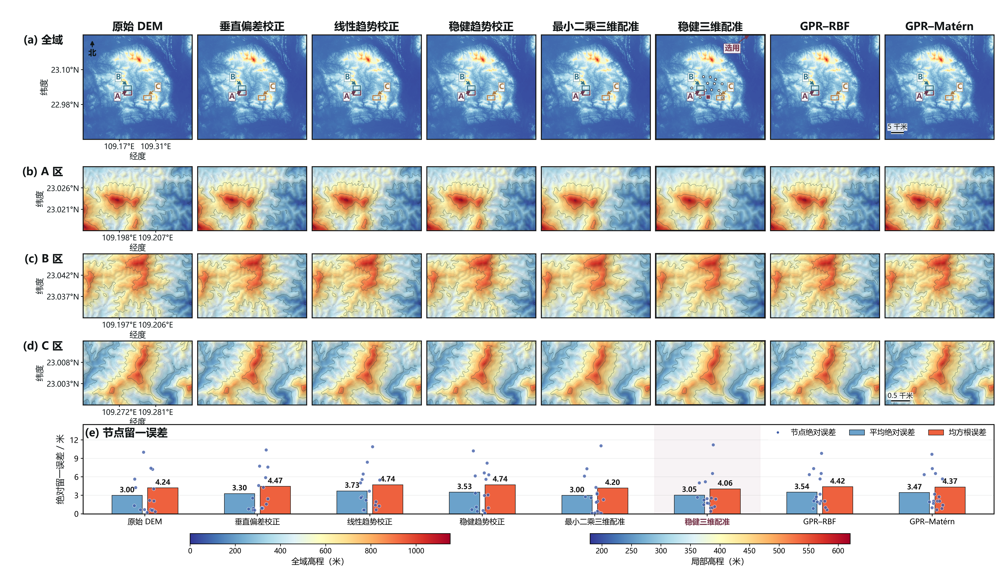

In [7]:
def touched_cells(x0,y0,x1,y1,width,height):
    dx0,dy0=x1-x0,y1-y0; times=[0.0,1.0]
    for start,delta in ((x0,dx0),(y0,dy0)):
        if abs(delta)>1e-14:
            for edge in range(math.floor(min(start,start+delta)),math.ceil(max(start,start+delta))+1):
                t=(edge-start)/delta
                if 0<t<1: times.append(t)
    times=sorted(set(round(t,12) for t in times)); result=set()
    probes=times+[(a+b)/2 for a,b in zip(times,times[1:])]
    for t in probes:
        x,y=x0+t*dx0,y0+t*dy0
        for col in {math.floor(x-1e-9),math.floor(x+1e-9)}:
            for row in {math.floor(y-1e-9),math.floor(y+1e-9)}:
                if 0<=col<width and 0<=row<height: result.add((row,col))
    return result

HERE=OUTPUT_ROOT
NODES=NODES_TABLE.set_index("node_id")
maps=products; raw=products["raw"]; left,top,dx,dy=LEFT,TOP,DX,DY
extent=(left,left+raw.shape[1]*dx,top-raw.shape[0]*dy,top)
names=[(code,"",None) for code in ("raw","bias","trend","robust_trend","ls","robust","rbf","matern")]
dm=max(float(np.quantile(np.abs(m.astype(np.float64)-raw),.95)) for m in maps.values())
diff_limit=max(15.0,5.0*math.ceil(dm/5.0))
vmin=50.0*math.floor(min(float(np.min(m)) for m in maps.values())/50)
vmax=50.0*math.ceil(max(float(np.max(m)) for m in maps.values())/50)
palette=plt.get_cmap("RdYlBu_r"); height_norm=Normalize(vmin=vmin,vmax=vmax)
diff_norm=TwoSlopeNorm(vmin=-diff_limit,vcenter=0,vmax=diff_limit); contrast=plt.get_cmap("RdBu_r")

def geo_xy(row):
    return float(row.longitude_deg),float(row.latitude_deg)


def pixel_of(node):
    n=NODES.loc[node]
    return ((n.longitude_deg-left)/dx,(top-n.latitude_deg)/dy)


def highest(site, data):
    x0,y0=pixel_of("O01")
    x1,y1=pixel_of(site)
    cells=touched_cells(x0,y0,x1,y1,raw.shape[1],raw.shape[0])
    row,col=max(cells,key=lambda rc:float(data[rc[0],rc[1]]))
    return (left+(col+.5)*dx,top-(row+.5)*dy,float(data[row,col]),row,col)


centers={s:highest(s,maps["robust"]) for s in ("S003","S015","S014")}
meters_lon=111320*math.cos(math.radians(float(NODES.loc["O01","latitude_deg"])))
half_lon=720/meters_lon
half_lat=720/111320
zoom_bounds={s:(v[0]-half_lon,v[0]+half_lon,v[1]-half_lat,v[1]+half_lat)
             for s,v in centers.items()}


def north_scale(ax, area, km=None, show_north=False, show_scale=False):
    x0,x1,y0,y1=area
    sx=x1-x0;sy=y1-y0
    if show_north:
        ax.annotate("北",xy=(x0+.085*sx,y0+.955*sy),xytext=(x0+.085*sx,y0+.825*sy),
                    fontsize=17,color="#101719",ha="center",va="center",fontweight="bold",
                    arrowprops={"arrowstyle":"-|>","lw":2.1,"color":"#101719"},zorder=15)
    if show_scale and km is not None:
        width=km*1000/meters_lon
        x=x0+.055*sx;y=y0+.065*sy
        ax.plot([x,x+width],[y,y],color="white",lw=6.2,zorder=14,solid_capstyle="butt")
        ax.plot([x,x+width],[y,y],color="#101719",lw=2.7,zorder=15,solid_capstyle="butt")
        ax.text(x+width/2,y+.018*sy,f"{km:g} 千米",fontsize=14.5,ha="center",va="bottom",
                color="#101719",zorder=16,
                bbox=dict(facecolor="white",edgecolor="none",alpha=.84,pad=.5))


def dem_slice(data,bounds):
    x0,x1,y0,y1=bounds
    c0=max(0,math.floor((x0-left)/dx))
    c1=min(raw.shape[1],math.ceil((x1-left)/dx))
    r0=max(0,math.floor((top-y1)/dy))
    r1=min(raw.shape[0],math.ceil((top-y0)/dy))
    return data[r0:r1,c0:c1],(left+c0*dx,left+c1*dx,top-r1*dy,top-r0*dy),(r0,r1,c0,c1)


def plot_one(ax,code,title,data,bounds,zoom_site=None,inset=True,locators=False,
             local_norm=None,show_coords=False,show_north=False,show_scale=False,
             scale_km=None,show_context=True):
    part,part_extent,indices=dem_slice(data,bounds)
    if zoom_site is not None:
        hill=LightSource(azdeg=305,altdeg=48).hillshade(
            part.astype(float),vert_exag=2.3,dx=30.,dy=30.)
        base=palette((local_norm or height_norm)(part.astype(float)))[..., :3]
        ax.imshow(base,origin="upper",extent=part_extent,
                  interpolation="nearest",rasterized=True)
        shadow=np.zeros((*hill.shape,4),dtype=float)
        shadow[...,3]=(1.-hill)*.22
        ax.imshow(shadow,origin="upper",extent=part_extent,
                  interpolation="nearest",rasterized=True,zorder=1)
        r0,r1,c0,c1=indices
        xc=left+(np.arange(c0,c1)+.5)*dx
        yc=top-(np.arange(r0,r1)+.5)*dy
        minor=np.arange(math.floor(float(part.min())/50)*50,
                        math.ceil(float(part.max())/50)*50+1,50)
        major=np.arange(math.floor(float(part.min())/100)*100,
                        math.ceil(float(part.max())/100)*100+1,100)
        if len(minor)>1:
            ax.contour(xc,yc,part,levels=minor,colors="#173744",
                       linewidths=.34,alpha=.24,zorder=2)
        if len(major)>1:
            ax.contour(xc,yc,part,levels=major,colors="#142e38",
                       linewidths=.72,alpha=.47,zorder=3)
    else:
        ax.imshow(part,origin="upper",extent=part_extent,cmap=palette,
                  vmin=vmin,vmax=vmax,interpolation="nearest",rasterized=True)
    ax.set_xlim(bounds[:2]);ax.set_ylim(bounds[2:])
    ax.set_aspect(1/math.cos(math.radians((bounds[2]+bounds[3])/2)))
    if show_coords:
        precision=2 if zoom_site is None else 3
        # Two interior ticks keep geographic labels readable after journal-page reduction.
        xt=np.linspace(bounds[0],bounds[1],4)[1:-1]
        yt=np.linspace(bounds[2],bounds[3],4)[1:-1]
        ax.set_xticks(xt);ax.set_yticks(yt)
        ax.set_xticklabels([f"{v:.{precision}f}°E" for v in xt])
        ax.set_yticklabels([f"{v:.{precision}f}°N" for v in yt])
        ax.tick_params(axis="both",which="major",direction="out",length=4.5,
                       width=1.6,labelsize=15.8,pad=3.5,colors="#101719")
        ax.set_xlabel("经度",fontsize=17.5,labelpad=3.0,color="#101719")
        ax.set_ylabel("纬度",fontsize=17.5,labelpad=4.5,color="#101719")
    else:
        ax.set_xticks([]);ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2.05 if code!="robust" else 3.0)
        spine.set_edgecolor("#151515")
    ax.set_title(title,fontsize=23.0,color="#111516",fontweight="semibold",pad=10)
    if code=="robust" and zoom_site is None:
        # The short diagonal arrow terminates on this panel's own top border.
        ax.annotate("选用",xy=(.86,.995),xycoords="axes fraction",
                    xytext=(.70,.87),textcoords="axes fraction",color="#76354a",
                    ha="center",va="center",fontsize=16.0,fontweight="semibold",
                    bbox=dict(facecolor="white",edgecolor="#76354a",linewidth=.7,
                              alpha=.92,pad=1.8),
                    arrowprops=dict(arrowstyle="-|>",lw=1.8,color="#76354a",
                                    connectionstyle="arc3,rad=-.08",
                                    shrinkA=4,shrinkB=1),zorder=20)
    if zoom_site is None and show_context:
        # Repeat the three locator boxes on every DEM product; keep nodes only
        # on the selected product so the eight-way comparison stays readable.
        if code=="robust":
            ax.scatter(NODES.loc[NODES.index!="O01","longitude_deg"],
                       NODES.loc[NODES.index!="O01","latitude_deg"],
                       s=21,facecolor="white",edgecolor="#272324",lw=1.1,zorder=10)
            ax.scatter([NODES.loc["O01","longitude_deg"]],
                       [NODES.loc["O01","latitude_deg"]],s=72,marker="s",
                       facecolor="#753850",edgecolor="white",lw=1.0,zorder=11)
        if locators:
            colors=("#65354d","#347387","#aa7d49")
            boxes=locators if isinstance(locators,dict) else zoom_bounds
            for (label,site),col in zip((("A","S003"),("B","S015"),("C","S014")),colors):
                xx0,xx1,yy0,yy1=boxes[site]
                ax.add_patch(patches.Rectangle((xx0,yy0),xx1-xx0,yy1-yy0,
                              fill=False,edgecolor="white",lw=3.4,zorder=11))
                ax.add_patch(patches.Rectangle((xx0,yy0),xx1-xx0,yy1-yy0,
                              fill=False,edgecolor=col,lw=2.2,zorder=12))
                offsets={"A":(-22,-13),"B":(-20,18),"C":(22,18)}
                ax.annotate(label,xy=((xx0+xx1)/2,yy1),xycoords="data",
                            xytext=offsets[label],textcoords="offset points",
                            color=col,ha="center",va="center",fontsize=16,
                            fontweight="bold",zorder=16,
                            bbox=dict(facecolor="white",edgecolor=col,linewidth=.8,
                                      alpha=.90,pad=1.0),
                            arrowprops=dict(arrowstyle="-|>",mutation_scale=15,
                                            lw=2.0,color=col,shrinkA=4,shrinkB=2))
    north_scale(ax,bounds,scale_km,show_north=show_north,show_scale=show_scale)
    if inset:
        da=(data.astype(np.float64)-raw)
        diff_part,_,_=dem_slice(da,bounds)
        sub=ax.inset_axes([.64,.045,.325,.32],zorder=17)
        sub.imshow(diff_part,extent=part_extent,origin="upper",cmap=contrast,
                   norm=diff_norm,interpolation="nearest",rasterized=True)
        sub.set_xticks([]);sub.set_yticks([])
        for spine in sub.spines.values():
            spine.set_color("#4a5458");spine.set_linewidth(.8)


def colorbars(fig):
    first=fig.add_axes([.14,.042,.31,.017])
    second=fig.add_axes([.56,.042,.31,.017])
    one=fig.colorbar(ScalarMappable(norm=height_norm,cmap=palette),cax=first,orientation="horizontal")
    two=fig.colorbar(ScalarMappable(norm=diff_norm,cmap=contrast),cax=second,
                     orientation="horizontal",extend="both")
    one.set_label("Elevation (m)",fontsize=9,labelpad=1)
    two.set_label("Change from raw (m)",fontsize=9,labelpad=1)
    two.set_ticks([-diff_limit,0,diff_limit])
    for bar in (one,two):
        bar.ax.tick_params(labelsize=8,length=2)
        bar.outline.set_linewidth(.5)


def panel_2x4(path,bounds,site=None):
    fig,axs=plt.subplots(2,4,figsize=(19,10.5),dpi=170,facecolor="white")
    fig.subplots_adjust(left=.016,right=.984,bottom=.105,top=.96,wspace=.032,hspace=.096)
    for ax,(code,label,_) in zip(axs.ravel(),names):
        plot_one(ax,code,label,maps[code],bounds,zoom_site=site,locators=site is None)
    colorbars(fig)
    fig.savefig(path,dpi=170,facecolor="white")
    plt.close(fig)


def atlas_3x8(path):
    # 上方全域，下面三处宽山脊带；局部八产品统一用 180–620 m。
    # 原始高度不变，只使用 RdYlBu_r 色带与局部统一的显示范围。
    atlas_bounds={}
    for site in ("S003","S015","S014"):
        x,y=centers[site][:2]
        atlas_bounds[site]=(x-1450/meters_lon,x+1450/meters_lon,
                            y-850/111320,y+850/111320)
    local_norm=Normalize(vmin=180,vmax=620)
    fig=plt.figure(figsize=(29.5,17.0),dpi=180,facecolor="white")
    gs=fig.add_gridspec(5,8,height_ratios=[1.72,1.02,1.02,1.02,1.28])
    axs=np.empty((4,8),dtype=object)
    for row in range(4):
        for col in range(8):
            axs[row,col]=fig.add_subplot(gs[row,col])
    stat_ax=fig.add_subplot(gs[4,:])
    fig.subplots_adjust(left=.083,right=.994,bottom=.108,top=.953,wspace=.050,hspace=.190)
    atlas_labels=("原始 DEM", "垂直偏差校正", "线性趋势校正", "稳健趋势校正",
                  "最小二乘三维配准", "稳健三维配准", "GPR–RBF", "GPR–Matérn")
    metrics=pd.read_csv(HERE/"09_八种DEM交叉验证与差异.csv",encoding="utf-8-sig").set_index("产品代号")
    node_errors=pd.read_csv(HERE/"11_八种DEM节点留一误差.csv",encoding="utf-8-sig")
    assert all(code in metrics.index for code,_,_ in names)
    assert set(node_errors["产品代号"])=={code for code,_,_ in names}
    row_label=("(a) 全域", "(b) A 区", "(c) B 区", "(d) C 区")
    for col,(code,label,_) in enumerate(names):
        plot_one(axs[0,col],code,atlas_labels[col],maps[code],extent,
                 zoom_site=None,locators=atlas_bounds,inset=False,
                 show_coords=(col==0),show_north=(col==0),
                 show_scale=(col==7),scale_km=5,show_context=True)
        for row,site in enumerate(("S003","S015","S014"),start=1):
            ax=axs[row,col]
            plot_one(ax,code,"",maps[code],atlas_bounds[site],
                     zoom_site=site,inset=False,local_norm=local_norm,
                     show_coords=(col==0),show_scale=(row==3 and col==7),
                     scale_km=.5)

    # 每个空间行只保留一套经纬度，其余面板共享同一范围。
    for row,label in enumerate(row_label):
        pos=axs[row,0].get_position()
        fig.text(pos.x0-.020,pos.y1,label,ha="right",va="top",
                 fontsize=23.0,fontweight="semibold",color="#111516")

    # 参考用户代码的柱形+抖动散点：柱为汇总指标，点为16个真实节点留一误差。
    xpos=np.arange(len(names),dtype=float)
    bar_width=.27
    mae_color=palette(.18)
    rmse_color=palette(.82)
    rng=np.random.default_rng(9)
    for col,(code,_,_) in enumerate(names):
        summary=metrics.loc[code]
        mae=float(summary["留一平均绝对误差米"])
        rmse=float(summary["留一均方根误差米"])
        stat_ax.bar(col-bar_width/1.7,mae,width=bar_width,color=mae_color,
                    edgecolor="#151515",linewidth=1.05,zorder=2)
        stat_ax.bar(col+bar_width/1.7,rmse,width=bar_width,color=rmse_color,
                    edgecolor="#151515",linewidth=1.05,zorder=2)
        vals=node_errors.loc[node_errors["产品代号"]==code,"留一绝对误差米"].to_numpy(float)
        jitter=rng.uniform(-.095,.095,len(vals))
        stat_ax.scatter(np.full(len(vals),col)+jitter,vals,s=52,
                        facecolor=palette(.06),edgecolor="white",
                        linewidth=.75,alpha=.78,zorder=4)
        stat_ax.text(col-bar_width/1.7,mae+.24,f"{mae:.2f}",ha="center",va="bottom",
                     fontsize=15.0,fontweight="semibold",color="#151515")
        stat_ax.text(col+bar_width/1.7,rmse+.24,f"{rmse:.2f}",ha="center",va="bottom",
                     fontsize=15.0,fontweight="semibold",color="#151515")
    stat_ax.axvspan(4.53,5.47,color="#76354a",alpha=.055,zorder=0)
    # Keep an empty in-axis band above the observed errors for the legend.
    stat_ax.set_xlim(-.55,7.55);stat_ax.set_ylim(0,14.5)
    stat_ax.set_xticks(xpos)
    stat_ax.set_xticklabels(atlas_labels,fontsize=16.0)
    stat_ax.get_xticklabels()[5].set_fontweight("bold")
    stat_ax.get_xticklabels()[5].set_color("#76354a")
    stat_ax.set_yticks([0,3,6,9,12])
    stat_ax.tick_params(axis="both",which="major",direction="out",length=5,
                        width=1.6,labelsize=16.0,pad=4.5,color="#151515")
    stat_ax.set_ylabel("绝对留一误差 / 米",fontsize=18.5,labelpad=9,color="#111516")
    stat_ax.grid(axis="y",color="#a9adae",lw=.65,alpha=.40,zorder=0)
    stat_ax.set_axisbelow(True)
    for spine in stat_ax.spines.values():
        spine.set_linewidth(2.0);spine.set_edgecolor("#151515")
    stat_ax.text(.002,.965,"(e) 节点留一误差",transform=stat_ax.transAxes,
                 ha="left",va="top",fontsize=23.0,fontweight="semibold",
                 color="#111516")
    handles=[Line2D([],[],marker="o",linestyle="none",markersize=6,
                    markerfacecolor=palette(.06),markeredgecolor="white",
                    label="节点绝对误差"),
             patches.Patch(facecolor=mae_color,edgecolor="#151515",label="平均绝对误差"),
             patches.Patch(facecolor=rmse_color,edgecolor="#151515",label="均方根误差")]
    stat_ax.legend(handles=handles,ncol=3,loc="upper right",bbox_to_anchor=(.995,.985),
                   frameon=True,facecolor="white",edgecolor="none",framealpha=.94,
                   fontsize=16.0,columnspacing=1.8,handletextpad=.7,borderaxespad=0)

    full_bar=fig.add_axes([.19,.056,.26,.018])
    local_bar=fig.add_axes([.59,.056,.26,.018])
    first=fig.colorbar(ScalarMappable(norm=height_norm,cmap=palette),
                       cax=full_bar,orientation="horizontal")
    second=fig.colorbar(ScalarMappable(norm=local_norm,cmap=palette),
                        cax=local_bar,orientation="horizontal")
    first.set_label("全域高程（米）",fontsize=17.5,labelpad=5)
    second.set_label("局部高程（米）",fontsize=17.5,labelpad=5)
    for bar in (first,second):
        bar.ax.tick_params(labelsize=15.0,length=5.0,width=1.3)
        bar.outline.set_linewidth(1.4)
    fig.savefig(path,dpi=180,facecolor="white")
    plt.close(fig)

t0=time.perf_counter(); log("开始绘制图 P2")
OUTPUT_FIGURE_2=OUTPUT_ROOT/"图P2_全域定位与三处局部放大_总览.png"
atlas_3x8(OUTPUT_FIGURE_2)
log(f"图 P2 完成：{OUTPUT_FIGURE_2}；耗时 {time.perf_counter()-t0:.2f} 秒")
display(Image.open(OUTPUT_FIGURE_2))

## 7. 最终检查与完整运行记录

In [7]:
assert len(products)==8 and len(METRICS)==8 and len(ERRORS)==128
assert all((layer_dir/f"{layer_names[k]}.tif").exists() for k in products)
assert OUTPUT_FIGURE_1.exists() and OUTPUT_FIGURE_2.exists()
selected=METRICS.set_index("产品代号").loc["robust"]
log(f"稳健三维配准 RMSE={selected['留一均方根误差米']:.3f} 米，MAE={selected['留一平均绝对误差米']:.3f} 米")
log("全部预处理、八图层导出、图 P1 与图 P2 已完成")
print("\n主要输出：")
print("图层目录：",layer_dir)
print("图 P1：",OUTPUT_FIGURE_1)
print("图 P2：",OUTPUT_FIGURE_2)
print("指标表：",OUTPUT_ROOT/"09_八种DEM交叉验证与差异.csv")

[2026-09-23 02:45:04] 稳健三维配准 RMSE=4.058 米，MAE=3.055 米
[2026-09-23 02:45:04] 全部预处理、八图层导出、图 P1 与图 P2 已完成
